## 15. Variational Autoencoders

- Remember to use tensorflow

In [2]:
#!pip install tensorflow
#!pip install pyod
#!pip install combo

In [1]:
######################
# Helper functions
######################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()

def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

def descriptive_stat_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm

In [2]:
X_train, X_test, y_train, y_test = DGP(n_features=25)

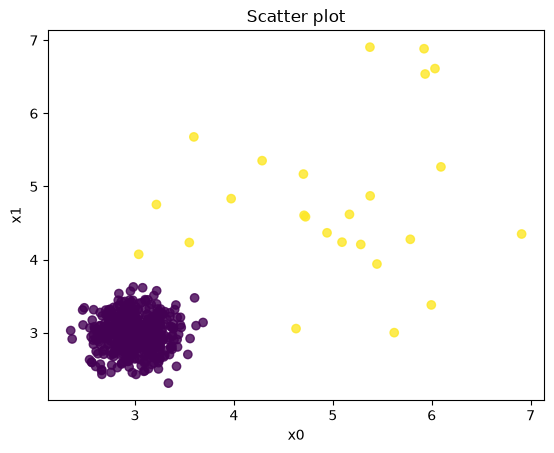

In [3]:
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [4]:
from pyod.models.vae import VAE
vae = VAE()
vae.fit(X_train)

Training: 100%|████████████████████████████████| 30/30 [00:00<00:00, 51.48it/s]


In [5]:
from pyod.models.vae import VAE
vae = VAE(
    encoder_neuron_list=[25, 12, 6],
    decoder_neuron_list=[6, 12, 25],
    latent_dim=4,
    contamination=0.05)
vae.fit(X_train)
print(vae)

Training: 100%|████████████████████████████████| 30/30 [00:00<00:00, 67.14it/s]

VAE(batch_norm=False, batch_size=32, beta=1.0, capacity=0.0,
  compile_mode='default', contamination=0.05,
  decoder_neuron_list=[6, 12, 25], device=device(type='cpu'),
  dropout_rate=0.2, encoder_neuron_list=[25, 12, 6], epoch_num=30,
  hidden_activation_name='relu', latent_dim=4, logvar_clip=(-30.0, 20.0),
  lr=0.001, optimizer_name='adam',
  optimizer_params={'weight_decay': 1e-05},
  output_activation_name='identity', preprocessing=True, random_state=42,
  use_compile=False, verbose=1)


In [6]:
results = evaluate_model(vae, X_train, X_test)
y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]
threshold = results["threshold"]

In [7]:
# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , threshold)
print("The training data:", count_stat(y_train_pred))
print("The test data:", count_stat(y_test_pred))

The threshold for the defined contamination rate: 4.127266
The training data: {np.int64(0): np.int64(475), np.int64(1): np.int64(25)}
The test data: {np.int64(0): np.int64(475), np.int64(1): np.int64(25)}


### Step 2: Determine the threshold

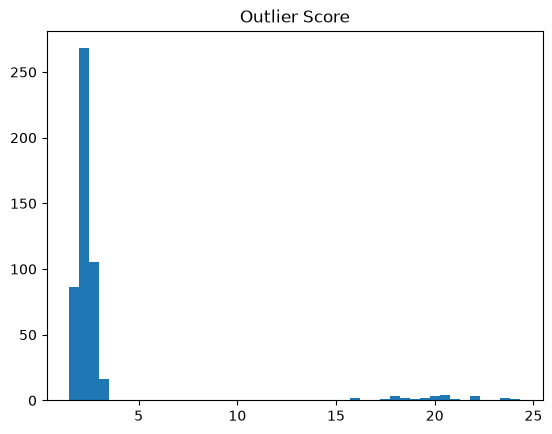

In [8]:
plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [9]:
feature_list = ['F01','F02','F03','F04','F05','F06','F07','F08','F09','F10','F11','F12',
'F13','F14','F15','F16','F17','F18','F19','F20','F21','F22','F23','F24','F25']
descriptive_stat_threshold(X_train,y_train_scores, threshold, feature_list)

,Group,Count,Count %,F01,F02,F03,F04,F05,F06,F07,...,F17,F18,F19,F20,F21,F22,F23,F24,F25,Anomaly_Score
0,Normal,475,95.0,2.99,2.99,2.98,3.00,3.00,3.00,3.0,...,3.01,2.98,2.99,3.00,3.01,3.00,3.0,2.99,3.01,2.300000
1,Outlier,25,5.0,5.02,4.79,5.05,4.87,4.99,5.32,4.8,...,5.07,5.30,4.89,4.82,4.86,5.28,4.8,4.91,5.10,19.969999


In [10]:
confusion_matrix(y_test,y_test_scores,threshold)

Pred,0,1
Actual,,
0.0,475,0
1.0,0,25


### Step 4: Averages

In [11]:
from pyod.models.vae import VAE
from pyod.models.combination import average
from pyod.utils.utility import standardizer
import numpy as np

# Option 1: Small VAE
vae1 = VAE(
    latent_dim=2,
    encoder_neuron_list=[25, 16, 8],
    decoder_neuron_list=[8, 16, 25]
)
# Option 2: Medium VAE
vae2 = VAE(
    latent_dim=2,
    encoder_neuron_list=[25, 16, 8, 4],
    decoder_neuron_list=[4, 8, 16, 25]
)
# Option 3: Larger VAE
vae3 = VAE(
    latent_dim=4,
    encoder_neuron_list=[25, 32, 16, 8],
    decoder_neuron_list=[8, 16, 32, 25]
)

# Fit models
vae1.fit(X_train)
vae2.fit(X_train)
vae3.fit(X_train)

# Store scores
train_scores = np.zeros((X_train.shape[0], 3))
test_scores = np.zeros((X_test.shape[0], 3))

train_scores[:,0] = vae1.decision_function(X_train)
train_scores[:,1] = vae2.decision_function(X_train)
train_scores[:,2] = vae3.decision_function(X_train)

test_scores[:,0] = vae1.decision_function(X_test)
test_scores[:,1] = vae2.decision_function(X_test)
test_scores[:,2] = vae3.decision_function(X_test)

# Normalize
train_scores_norm, test_scores_norm = standardizer(
    train_scores,
    test_scores
)

# Aggregate
y_train_avg = average(train_scores_norm)
y_test_avg = average(test_scores_norm)

Training: 100%|████████████████████████████████| 30/30 [00:00<00:00, 54.75it/s]


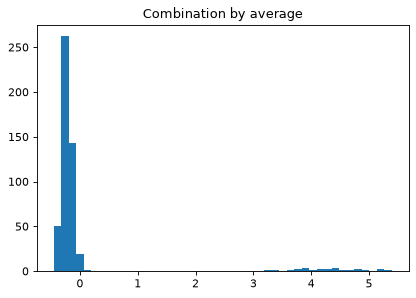

In [12]:
plt.figure(figsize=(6, 4), dpi=80)
# Combination by average
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)
plot_hist(y_train_by_average, title="Combination by average")

In [17]:
descriptive_stat_threshold(X_train,y_train_by_average, 0.9, feature_list)

,Group,Count,Count %,F01,F02,F03,F04,F05,F06,F07,...,F17,F18,F19,F20,F21,F22,F23,F24,F25,Anomaly_Score
0,Normal,475,95.0,2.99,2.99,2.98,3.00,3.00,3.00,3.0,...,3.01,2.98,2.99,3.00,3.01,3.00,3.0,2.99,3.01,-0.23
1,Outlier,25,5.0,5.02,4.79,5.05,4.87,4.99,5.32,4.8,...,5.07,5.30,4.89,4.82,4.86,5.28,4.8,4.91,5.10,4.31


In [18]:
descriptive_stat_threshold(X_test,y_test_by_average, 0.9, feature_list)

,Group,Count,Count %,F01,F02,F03,F04,F05,F06,F07,...,F17,F18,F19,F20,F21,F22,F23,F24,F25,Anomaly_Score
0,Normal,475,95.0,3.00,3.02,2.98,2.99,3.01,2.99,3.01,...,3.00,3.0,2.99,3.00,3.00,3.01,2.99,3.02,3.01,-0.23
1,Outlier,25,5.0,5.22,5.45,4.96,5.26,5.34,5.14,4.88,...,5.07,5.1,4.85,4.98,5.36,4.88,4.50,5.08,4.64,4.48
